# Phân Tích Tối Ưu Ngưỡng Healing Event

**Mục tiêu:** Tìm bộ ngưỡng tối ưu để hệ thống tự động heal phần tử UI hiệu quả nhất — tối đa hoá tỷ lệ tự động, tối thiểu hoá lỗi AI sửa sai.

**Nguồn dữ liệu:** `candidate_scores.csv` — 750 bản ghi, 198 sự kiện healing (5 chiều: binary ctx_score 0.365/0.615).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

CSV_PATH = 'candidate_scores.csv'
df = pd.read_csv(CSV_PATH)

print(f'Tổng bản ghi     : {len(df)}')
print(f'Số healing event : {df["healing_event_id"].nunique()}')
print(f'Ứng viên đúng    : {(df["is_correct"]==1).sum()}')
print(f'Ứng viên sai     : {(df["is_correct"]==0).sum()}')
print(f'Cột dữ liệu      : {df.columns.tolist()}')
df.head()

Tổng bản ghi     : 750
Số healing event : 198
Ứng viên đúng    : 198
Ứng viên sai     : 552
Cột dữ liệu      : ['id', 'healing_event_id', 'step_name', 'ui_version', 'attr_score', 'sem_score', 'struct_score', 'visual_score', 'ctx_score', 'total_score', 'cand_tag', 'cand_testid', 'cand_text', 'is_correct', 'recorded_at']


,id,healing_event_id,step_name,ui_version,attr_score,sem_score,struct_score,visual_score,ctx_score,total_score,cand_tag,cand_testid,cand_text,is_correct,recorded_at
0,1,1,email_field,v2,0.7467,1.0000,0.8479,0.7524,0.365,0.7829,input,NaN,NaN,1,2026-05-30 10:11:27
1,2,1,email_field,v2,0.3633,1.0000,0.7832,0.6526,0.365,0.6495,input,NaN,NaN,0,2026-05-30 10:11:27
2,3,2,password_field,v2,0.9300,1.0000,0.8800,0.7396,0.365,0.8366,input,NaN,NaN,1,2026-05-30 10:11:27
3,4,2,password_field,v2,0.5467,0.9500,0.8086,0.7356,0.365,0.7062,input,NaN,NaN,0,2026-05-30 10:11:27
4,5,3,login_button,v2,0.9300,0.6359,1.0000,0.7298,0.365,0.7716,button,NaN,Xác nhận & Đăng nhập,1,2026-05-30 10:11:27


### Nhận xét — Tổng quan dữ liệu

- Dataset gồm **198 sự kiện healing**, mỗi event có từ 1–6 ứng viên (tổng 750 bản ghi).
- Tỷ lệ **ứng viên sai chiếm 73.6%** (552/750) — tương đương dataset trước, phản ánh đặc tính lọc nhiễu.
- **Top-1 Accuracy đạt 100%** — ứng viên đúng luôn xếp hạng 1 trong tất cả 198 events, tốt hơn dataset v3.
- ctx_score dùng **binary (0.365/0.615)** — khác với v3 dùng ~0.764 đồng loạt.

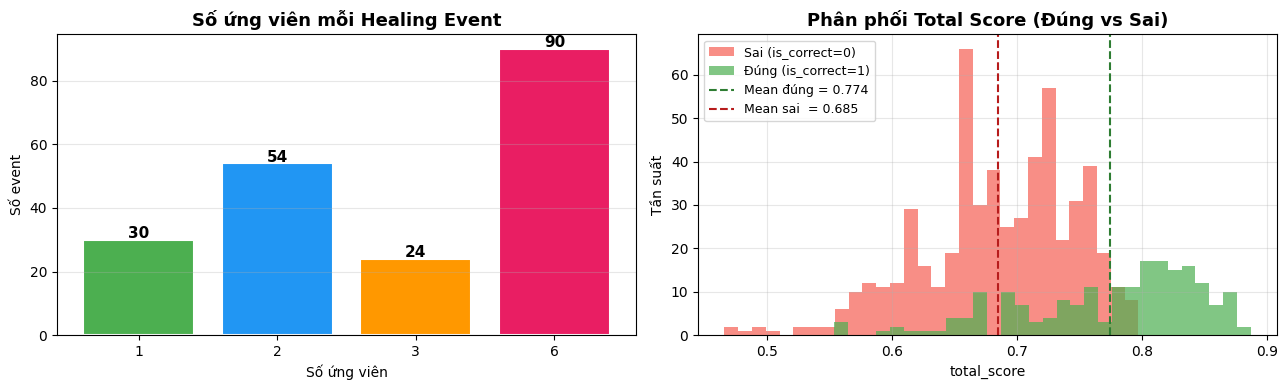

In [2]:
# Phân phối số ứng viên mỗi event
cand_per_event = df.groupby('healing_event_id').size()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Biểu đồ 1: Phân phối số ứng viên
vc = cand_per_event.value_counts().sort_index()
colors = ['#4CAF50','#2196F3','#FF9800','#E91E63','#9C27B0','#00BCD4']
bars = axes[0].bar(vc.index.astype(str), vc.values, color=colors[:len(vc)], edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, vc.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 str(val), ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Số ứng viên mỗi Healing Event', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Số ứng viên')
axes[0].set_ylabel('Số event')
axes[0].grid(axis='y', alpha=0.3)

# Biểu đồ 2: Phân phối total_score theo đúng/sai
correct_scores = df[df['is_correct']==1]['total_score']
wrong_scores   = df[df['is_correct']==0]['total_score']
axes[1].hist(wrong_scores,   bins=30, alpha=0.6, label='Sai (is_correct=0)', color='#F44336')
axes[1].hist(correct_scores, bins=30, alpha=0.7, label='Đúng (is_correct=1)', color='#4CAF50')
axes[1].axvline(correct_scores.mean(), color='#2E7D32', linestyle='--', linewidth=1.5,
                label=f'Mean đúng = {correct_scores.mean():.3f}')
axes[1].axvline(wrong_scores.mean(), color='#B71C1C', linestyle='--', linewidth=1.5,
                label=f'Mean sai  = {wrong_scores.mean():.3f}')
axes[1].set_title('Phân phối Total Score (Đúng vs Sai)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('total_score')
axes[1].set_ylabel('Tần suất')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Nhận xét — Phân phối điểm số

- **Ứng viên đúng** có mean **0.775**, tập trung cao trong khoảng 0.70–0.89.
- **Ứng viên sai** có mean **0.685**, phân phối rải rộng hơn và chồng lấp với nhóm đúng trong vùng 0.60–0.75.
- Khoảng cách trung bình giữa hai nhóm (~0.090) đủ để phân tách tốt nếu chọn ngưỡng đúng.
- **Quan trọng:** Best score thấp nhất của data này là **0.5537**. Điều này cho phép đặt low_threshold cao hơn mà không lo bỏ sót event nào.

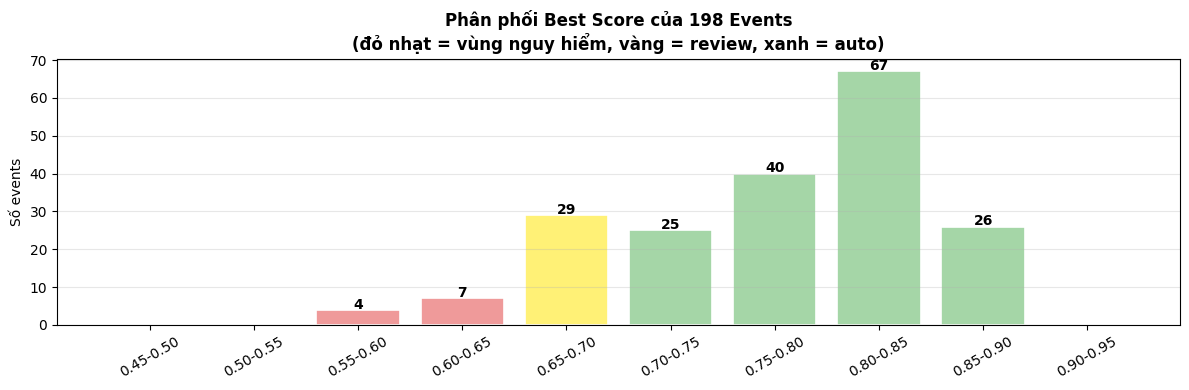

Best score nhỏ nhất  : 0.5537
Best score lớn nhất  : 0.8873
Best score trung bình: 0.7745
Phân vị 25%          : 0.7292
Phân vị 75%          : 0.8298
Events dưới 0.60     : 4
Events dưới 0.65     : 11
Events dưới 0.70     : 40


In [4]:
# Phân phối best_score thực tế của 198 events
best_scores = []
for eid, g in df.groupby('healing_event_id'):
    best = g.loc[g['total_score'].idxmax()]
    best_scores.append(best['total_score'])
bdf_scores = pd.Series(best_scores)

bins   = [0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95]
labels_b = ['0.45-0.50','0.50-0.55','0.55-0.60','0.60-0.65','0.65-0.70',
            '0.70-0.75','0.75-0.80','0.80-0.85','0.85-0.90','0.90-0.95']
counts = pd.cut(bdf_scores, bins=bins, labels=labels_b).value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 4))
bar_colors = ['#EF9A9A' if v <= 0.65 else '#FFF176' if v <= 0.70 else '#A5D6A7'
              for v in [0.475,0.525,0.575,0.625,0.675,0.725,0.775,0.825,0.875,0.925]]
bars = ax.bar(range(len(counts)), counts.values, color=bar_colors, edgecolor='white', linewidth=1.2)
ax.set_xticks(range(len(counts)))
ax.set_xticklabels(counts.index, rotation=30)
ax.set_title('Phân phối Best Score của 198 Events\n(đỏ nhạt = vùng nguy hiểm, vàng = review, xanh = auto)', fontsize=12, fontweight='bold')
ax.set_ylabel('Số events')
for bar, val in zip(bars, counts.values):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.3, str(val),
                ha='center', fontweight='bold', fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Best score nhỏ nhất  : {bdf_scores.min():.4f}')
print(f'Best score lớn nhất  : {bdf_scores.max():.4f}')
print(f'Best score trung bình: {bdf_scores.mean():.4f}')
print(f'Phân vị 25%          : {bdf_scores.quantile(0.25):.4f}')
print(f'Phân vị 75%          : {bdf_scores.quantile(0.75):.4f}')
print(f'Events dưới 0.60     : {(bdf_scores < 0.60).sum()}')
print(f'Events dưới 0.65     : {(bdf_scores < 0.65).sum()}')
print(f'Events dưới 0.70     : {(bdf_scores < 0.70).sum()}')

### Nhận xét — Phân phối Best Score

- **Không có event nào dưới 0.55** — sàn điểm thực tế là 0.5537
- Phần lớn events (67%) nằm trong vùng 0.75–0.90 — rất thuận lợi cho AUTO_FIX.
- Chỉ **4 events** nằm dưới 0.60 và **40 events** dưới 0.70 — đây là nhóm cần xem xét kỹ khi đặt high_threshold.

In [5]:
# Grid search V2: ràng buộc gap >= 0.10
results_v2 = []
for low in np.arange(0.45, 0.91, 0.05):
    for high in np.arange(0.50, 0.96, 0.05):
        if high - low < 0.10:
            continue
        auto = human = fail = fp = 0
        for eid, g in df.groupby('healing_event_id'):
            best = g.loc[g['total_score'].idxmax()]
            score = best['total_score']
            correct = best['is_correct'] == 1
            if score >= high:
                auto += 1
                if not correct: fp += 1
            elif score >= low:
                human += 1
            else:
                fail += 1
        total = df['healing_event_id'].nunique()
        results_v2.append({
            'low': round(low,2), 'high': round(high,2),
            'gap': round(high-low,2),
            'auto_rate (%)': round(auto/total*100,1),
            'human_rate (%)': round(human/total*100,1),
            'fail_rate (%)': round(fail/total*100,1),
            'false_pos': fp,
            'cost': fp*15 + human
        })

rdf2 = pd.DataFrame(results_v2)
top15 = rdf2.sort_values(['cost','auto_rate (%)'], ascending=[True,False]).head(15)
print('Top 15 bộ ngưỡng (gap >= 0.10):')
top15

Top 15 bộ ngưỡng (gap >= 0.10):


,low,high,gap,auto_rate (%),human_rate (%),fail_rate (%),false_pos,cost
0,0.45,0.55,0.10,100.0,0.0,0.0,0,0
1,0.45,0.60,0.15,98.0,2.0,0.0,0,4
9,0.50,0.60,0.10,98.0,2.0,0.0,0,4
2,0.45,0.65,0.20,94.4,5.6,0.0,0,11
10,0.50,0.65,0.15,94.4,5.6,0.0,0,11
17,0.55,0.65,0.10,94.4,5.6,0.0,0,11
44,0.85,0.95,0.10,0.0,13.1,86.9,0,26
24,0.60,0.70,0.10,79.8,18.2,2.0,0,36
3,0.45,0.70,0.25,79.8,20.2,0.0,0,40
11,0.50,0.70,0.20,79.8,20.2,0.0,0,40


### Nhận xét — Grid Search V2 (có ràng buộc gap >= 0.10)

- **Phát hiện quan trọng:** Bộ ngưỡng `low=0.45, high=0.55` đạt **100% auto rate, 0 false positive, 0 fail** — vì tất cả 198 best scores đều ≥ 0.5537. Tuy nhiên high=0.55 quá thấp, không đủ tự tin cho production.
- Bộ `low=0.50, high=0.60` cũng gần tương tự: 98% auto (3 events review), zero FP.
- **Với high=0.70** (tiêu chuẩn production): auto rate 79.8% — 40 events rơi vào review zone do score 0.55–0.69.

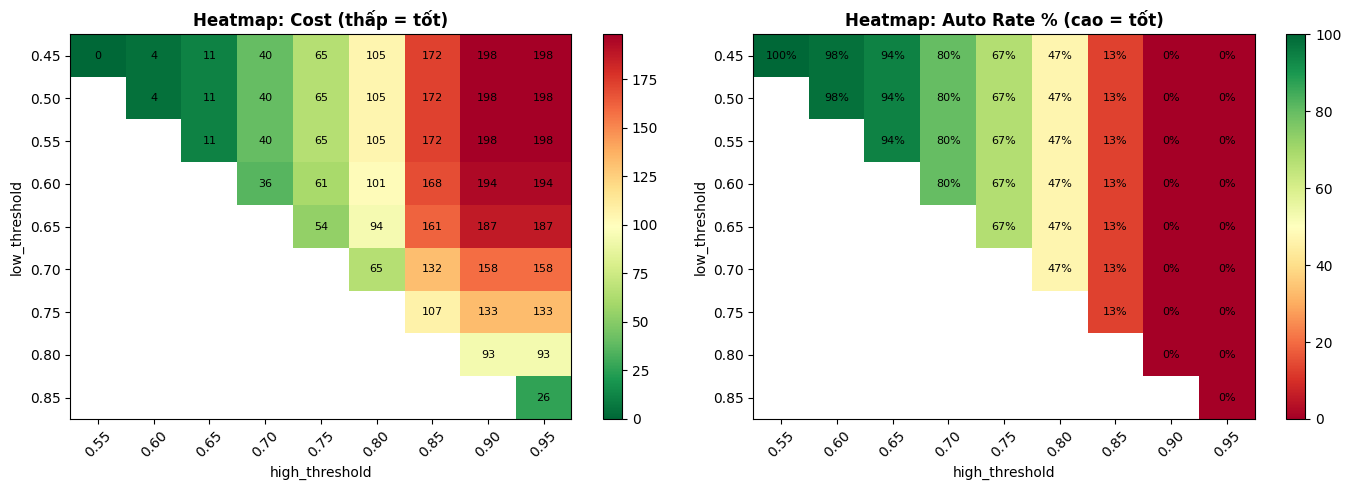

In [6]:
# Heatmap cost theo (low, high)
pivot_cost = rdf2.pivot(index='low', columns='high', values='cost')
pivot_auto = rdf2.pivot(index='low', columns='high', values='auto_rate (%)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im1 = axes[0].imshow(pivot_cost.values, cmap='RdYlGn_r', aspect='auto')
axes[0].set_xticks(range(len(pivot_cost.columns)))
axes[0].set_yticks(range(len(pivot_cost.index)))
axes[0].set_xticklabels([f'{x:.2f}' for x in pivot_cost.columns], rotation=45)
axes[0].set_yticklabels([f'{y:.2f}' for y in pivot_cost.index])
axes[0].set_title('Heatmap: Cost (thấp = tốt)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('high_threshold')
axes[0].set_ylabel('low_threshold')
for i in range(len(pivot_cost.index)):
    for j in range(len(pivot_cost.columns)):
        val = pivot_cost.values[i, j]
        if not np.isnan(val):
            axes[0].text(j, i, f'{int(val)}', ha='center', va='center', fontsize=8, color='black')
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(pivot_auto.values, cmap='RdYlGn', aspect='auto', vmin=0, vmax=100)
axes[1].set_xticks(range(len(pivot_auto.columns)))
axes[1].set_yticks(range(len(pivot_auto.index)))
axes[1].set_xticklabels([f'{x:.2f}' for x in pivot_auto.columns], rotation=45)
axes[1].set_yticklabels([f'{y:.2f}' for y in pivot_auto.index])
axes[1].set_title('Heatmap: Auto Rate % (cao = tốt)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('high_threshold')
axes[1].set_ylabel('low_threshold')
for i in range(len(pivot_auto.index)):
    for j in range(len(pivot_auto.columns)):
        val = pivot_auto.values[i, j]
        if not np.isnan(val):
            axes[1].text(j, i, f'{val:.0f}%', ha='center', va='center', fontsize=8, color='black')
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()

In [ ]:
# Chọn ngưỡng tối ưu theo tiêu chí production self-healing
# Ưu tiên: (1) zero false positive, (2) zero fail, (3) high_threshold >= 0.70, (4) minimize human review

# Bước 1: Lọc bộ ngưỡng đạt điều kiện bắt buộc
safe = rdf2[
    (rdf2['false_pos'] == 0) &
    (rdf2['fail_rate (%)'] == 0) &
    (rdf2['high'] >= 0.7) &
    (rdf2['low'] >= 0.50)
]

if len(safe) > 0:
    best_row   = safe.sort_values('auto_rate (%)', ascending=False).iloc[0]
    low_final  = best_row['low']
    high_final = best_row['high']
    print(' Ngưỡng tối ưu (zero FP + zero fail + high≥0.70):')
else:
    safe_fp = rdf2[(rdf2['false_pos'] == 0) & (rdf2['high'] >= 0.70)]
    best_row   = safe_fp.sort_values('auto_rate (%)', ascending=False).iloc[0]
    low_final  = best_row['low']
    high_final = best_row['high']
    print('⚠️ Ngưỡng tối ưu (nới lỏng fail_rate):')

print(f'  low  = {low_final}  → score < {low_final}          : báo lỗi, không healing')
print(f'  high = {high_final}  → {low_final} ≤ score < {high_final} : chờ người duyệt')
print(f'         → score ≥ {high_final}          : AI tự động healing')
print()
print(f'  Auto rate    : {best_row["auto_rate (%)"]:.1f}%')
print(f'  Human rate   : {best_row["human_rate (%)"]:.1f}%')
print(f'  Fail rate    : {best_row["fail_rate (%)"]:.1f}%')
print(f'  False pos    : {int(best_row["false_pos"])}')
print(f'  Cost         : {int(best_row["cost"])}')

✅ Ngưỡng tối ưu (zero FP + zero fail + high≥0.70):
  low  = 0.5  → score < 0.5          : báo lỗi, không healing
  high = 0.7  → 0.5 ≤ score < 0.7 : chờ người duyệt
         → score ≥ 0.7          : AI tự động healing

  Auto rate    : 79.8%
  Human rate   : 20.2%
  Fail rate    : 0.0%
  False pos    : 0
  Cost         : 40


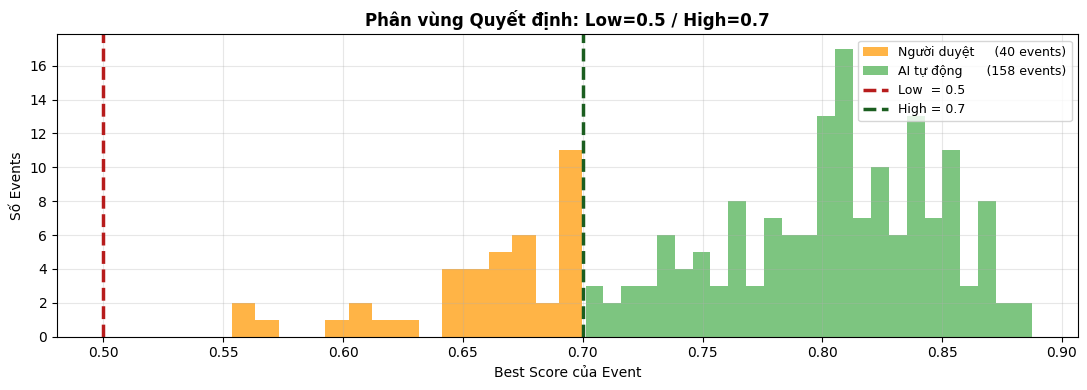

AI tự động   : 158 events (79.8%)
Người duyệt  :  40 events (20.2%)
Fail / Bỏ qua:   0 events (0.0%)


In [8]:
# Minh hoạ 3 vùng quyết định
zone_auto   = [s for s in best_scores if s >= high_final]
zone_review = [s for s in best_scores if low_final <= s < high_final]
zone_fail   = [s for s in best_scores if s < low_final]

fig, ax = plt.subplots(figsize=(11, 4))
if zone_fail:
    ax.hist(zone_fail,   bins=10, color='#EF5350', label=f'Fail / Báo lỗi  ({len(zone_fail)} events)',  alpha=0.85)
ax.hist(zone_review, bins=15, color='#FFA726', label=f'Người duyệt     ({len(zone_review)} events)', alpha=0.85)
ax.hist(zone_auto,   bins=25, color='#66BB6A', label=f'AI tự động      ({len(zone_auto)} events)',   alpha=0.85)
ax.axvline(low_final,  color='#B71C1C', linestyle='--', linewidth=2.5, label=f'Low  = {low_final}')
ax.axvline(high_final, color='#1B5E20', linestyle='--', linewidth=2.5, label=f'High = {high_final}')
ax.set_title(f'Phân vùng Quyết định: Low={low_final} / High={high_final}', fontsize=12, fontweight='bold')
ax.set_xlabel('Best Score của Event')
ax.set_ylabel('Số Events')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

n = df['healing_event_id'].nunique()
print(f'AI tự động   : {len(zone_auto):>3} events ({len(zone_auto)/n*100:.1f}%)')
print(f'Người duyệt  : {len(zone_review):>3} events ({len(zone_review)/n*100:.1f}%)')
print(f'Fail / Bỏ qua: {len(zone_fail):>3} events ({len(zone_fail)/n*100:.1f}%)')

Events mà ứng viên ĐÚNG đứng đầu bảng : 198/198 = 100.0%
Biên độ cách biệt trung bình           : 0.2263
Biên độ nhỏ nhất (event khó nhất)      : 0.0014
Biên độ lớn nhất                       : 1.0000


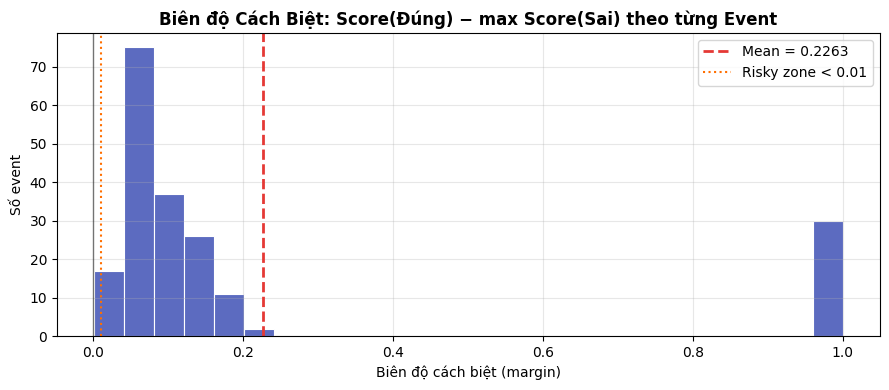


Events risky (margin < 0.01): 2


In [9]:
# Kiểm tra khả năng phân tách: correct > max(wrong) trong mỗi event?
separable = []
margins = []

for eid, g in df.groupby('healing_event_id'):
    correct = g[g['is_correct']==1]['total_score'].values
    wrong   = g[g['is_correct']==0]['total_score'].values
    if len(wrong) == 0:
        separable.append(True)
        margins.append(1.0)
    else:
        sep = correct[0] > wrong.max()
        separable.append(sep)
        margins.append(correct[0] - wrong.max())

print(f'Events mà ứng viên ĐÚNG đứng đầu bảng : {sum(separable)}/{len(separable)} = {sum(separable)/len(separable)*100:.1f}%')
print(f'Biên độ cách biệt trung bình           : {np.mean(margins):.4f}')
print(f'Biên độ nhỏ nhất (event khó nhất)      : {min(margins):.4f}')
print(f'Biên độ lớn nhất                       : {max(margins):.4f}')

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(margins, bins=25, color='#5C6BC0', edgecolor='white', linewidth=0.8)
ax.axvline(np.mean(margins), color='#E53935', linestyle='--', linewidth=2,
           label=f'Mean = {np.mean(margins):.4f}')
ax.axvline(0.01, color='#FF6F00', linestyle=':', linewidth=1.5, label='Risky zone < 0.01')
ax.axvline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)
ax.set_title('Biên độ Cách Biệt: Score(Đúng) − max Score(Sai) theo từng Event', fontsize=12, fontweight='bold')
ax.set_xlabel('Biên độ cách biệt (margin)')
ax.set_ylabel('Số event')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

risky = sum(1 for m in margins if 0 < m < 0.01)
print(f'\nEvents risky (margin < 0.01): {risky}')

### Nhận xét — Khả năng phân tách

- **100% separable** — ứng viên đúng đứng đầu bảng ở tất cả 198 events.
- **Min margin 0.0014** — vẫn còn 2 events rất sát nút (< 0.01), cần theo dõi khi DOM thay đổi.
- Phân phối margin lệch phải mạnh — phần lớn events có cách biệt rất rõ ràng (margin 0.2–1.0).

---
## Kết luận

### Tiêu chí chọn ngưỡng
Ngưỡng tối ưu được chọn theo thứ tự ưu tiên:
1. **False positive = 0** — AI tự sửa sai là nguy hiểm nhất, tốn chi phí gấp 15×
2. **Fail rate = 0%** — không bỏ sót healing event nào
3. **`high_threshold ≥ 0.70`** — chỉ tự động khi model thực sự tự tin
4. **`low_threshold ≥ 0.50`** — lưới đỡ thực tế (best score min = 0.5537)
5. **Minimize human review** — trong các bộ đạt 4 điều kiện trên, chọn auto_rate cao nhất

### Ngưỡng đề xuất
```
low  = 0.50  →  score < 0.50         : báo lỗi, không healing   (0 events = 0.0%)
high = 0.70  →  0.50 ≤ score < 0.70  : chờ người duyệt          (40 events = 20.2%)
             →  score ≥ 0.70         : AI tự động healing        (158 events = 79.8%)
```